# <font color=blue>Stitching de Imágenes</font>


**Objetivos:**
Implementar los pasos para lograr generar una imagen panoramica.

## <font color=green> Ejercicio 1:  Importar bibliotecas necesarias</font>

**Nomre:** Manuel Ramírez Galván

**Fecha:** 21/03/2025

**Actividad** 3

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## <font color=green> Ejercicio 2: Preparación de Imágenes</font>

**Objetivo:** Preparar las imagenes para realizar el stitching.

**Pasos:**
1.   Cargar las imagenes img1.jpg y img2.jpg con `cv2.imread()`.
2.   Verifica el tamaño de las imagenes si no es igual redimencionalas con `cv2.resize()`.
3.   Convertir las imágenes a escala de grises`cv2.cvtColor()`.
5.   Mostrar las dos imagenes a color `plt.imshow()`.

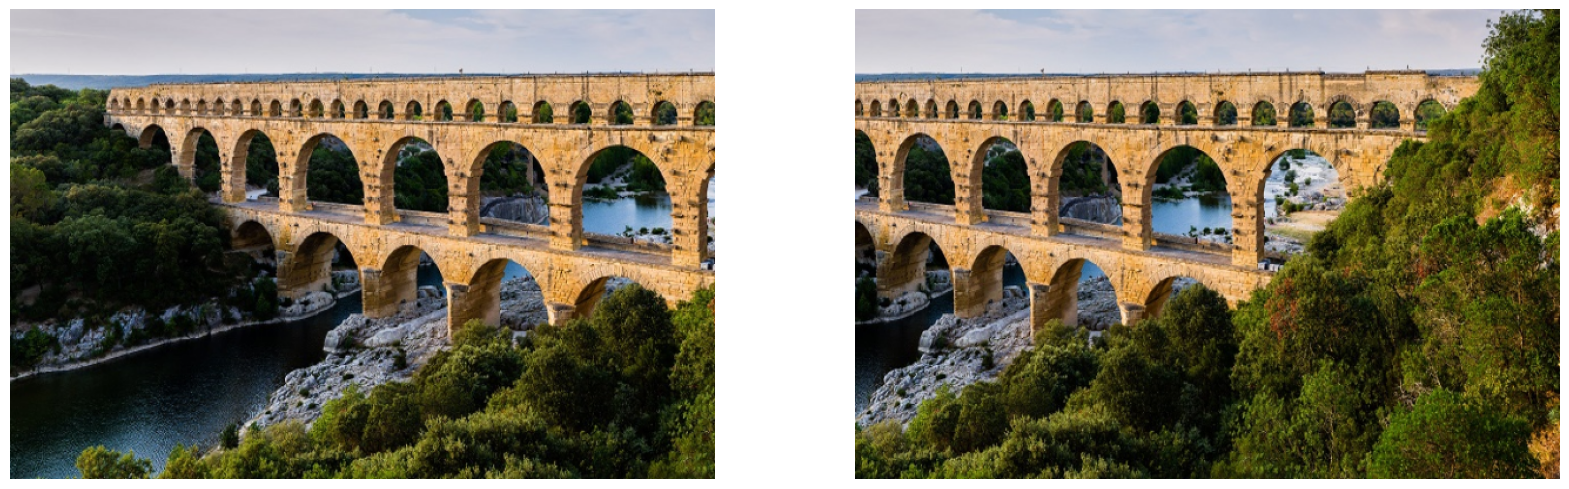

In [10]:
img1_path = cv2.imread('data/img1.jpg')
img2_path = cv2.imread('data/img2.jpg')

img1 = cv2.resize(img1_path, (600, 400))
img2 = cv2.resize(img2_path, (600, 400))

img1_g = cv2.cvtColor(img1_path, cv2.COLOR_BGR2GRAY)
img2_g = cv2.cvtColor(img2_path, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## <font color=green> Ejercicio 3: Detección de Puntos Clave </font>

**Objetivo:** Detectar y visualizar puntos clave en dos imágenes.

**Pasos:**
1.   Crea el detector de los puntos claves en ambas imagenes utiliza el metodo que quieras.
2.   Detectar puntos clave y descriptores con `detector.detectAndCompute()`.
3.   Dibujar los puntos clave detectados sobre las imágenes con `cv2.drawKeypoints()`.
4.   Mostrar las imágenes resultantes con `plt.imshow()`.

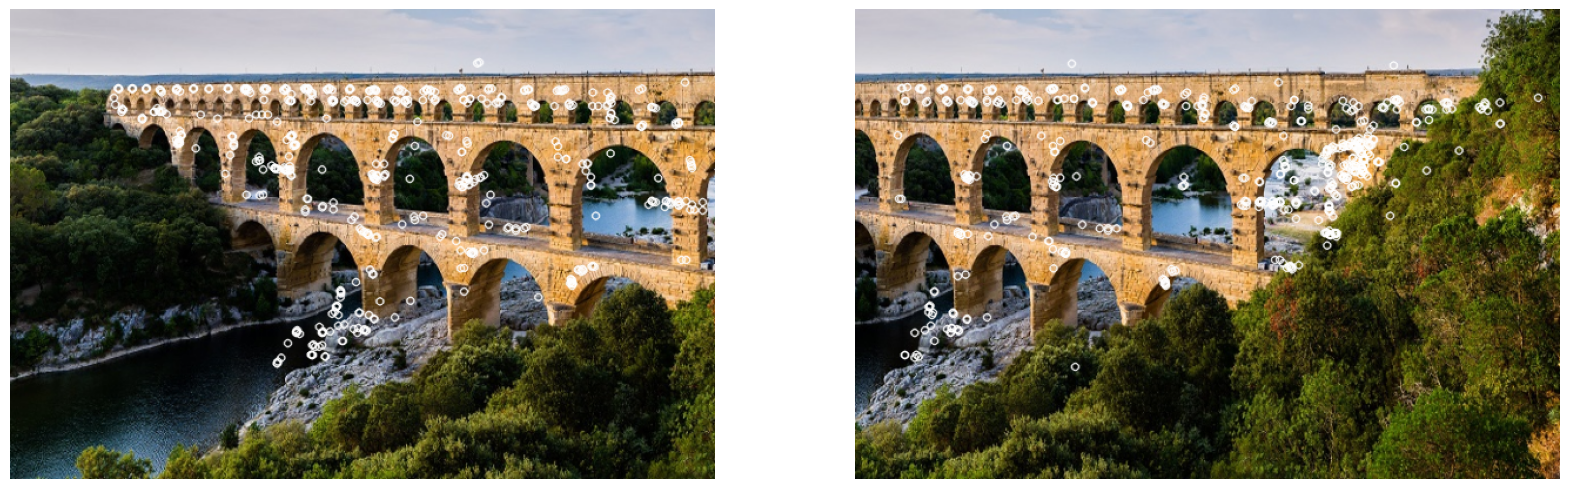

In [11]:
detector = cv2.ORB_create(nfeatures=500)

keypoints1, descriptors1 = detector.detectAndCompute(img1_g, None)
keypoints2, descriptors2 = detector.detectAndCompute(img2_g, None)

points1 =cv2.drawKeypoints(img1, keypoints1, None, color=(255, 255, 255))
points2 =cv2.drawKeypoints(img2, keypoints2, None, color=(255, 255, 255))

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(points1, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(points2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## <font color=green> Ejercicio 4:  Emparejamiento de Características </font>

**Objetivo:** Emparejar puntos clave entre dos imágenes utilizando descriptores ORB y el algoritmo de correspondencia BFMatcher con NORM_HAMMING.

**Pasos:**
1. Crear el emparejador BFMatcher con `cv2.BFMatcher()`.
2. Comparar descriptores entre ambas imágenes con `bf.match()`.
3. Ordenar las coincidencias por distancia con `sorted()`.
4. Dibujar las correspondencias más relevantes con `cv2.drawMatches()`.
5. Mostrar las coincidencias en las imágenes con `plt.imshow()`.

(np.float64(-0.5), np.float64(1199.5), np.float64(399.5), np.float64(-0.5))

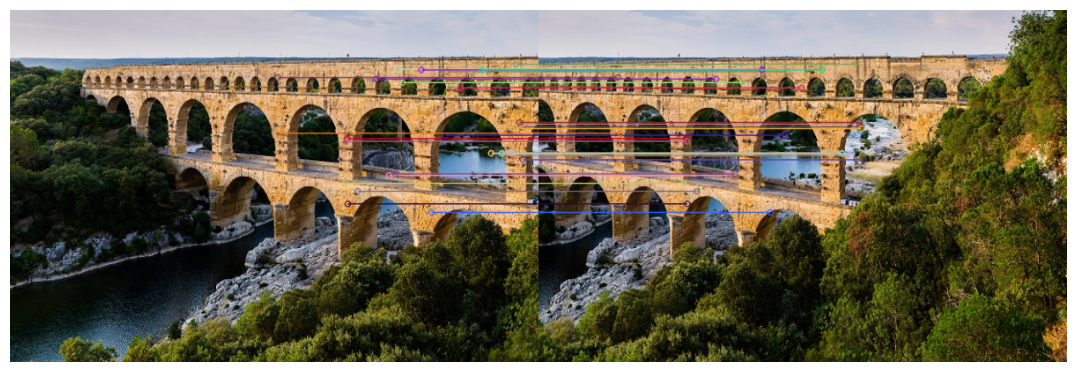

In [12]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

img_m = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:30], None, flags=2)

plt.figure(figsize=(30, 20))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_m, cv2.COLOR_BGR2RGB))
plt.axis("off")

## <font color=green> Ejercicio 5:  Emparejamiento de Características </font>

**Objetivo:** Calcular la matriz de homografía entre dos imágenes usando puntos clave emparejados.

**Pasos:**
1. Extraer los puntos clave coincidentes de ambas imágenes en formato `float32`.
2. Calcular la homografía con `cv2.findHomography()`, utilizando `RANSAC` para eliminar outliers.
3. Verificar si la homografía fue encontrada correctamente.
4. Imprimir la matriz de homografía.

In [13]:
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in matches[:30]]).reshape(-1, 1, 2)
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in matches[:30]]).reshape(-1, 1, 2)

homografy, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

print(homografy)

[[ 9.96786973e-01 -1.20170577e-02 -2.12421034e+02]
 [-3.63108392e-04  9.91219907e-01  5.68132308e-01]
 [-4.15962452e-06 -2.53374372e-05  1.00000000e+00]]


## <font color=green> Ejercicio 6:  Alineación de Imágenes </font>

**Objetivo:** Alinear dos imágenes usando la matriz de homografía para corregir perspectiva y superponerlas correctamente.

**Pasos:**
1. Obtener las dimensiones de ambas imágenes.
2. Transformar las esquinas de la imagen1 con `cv2.perspectiveTransform()` para ver hasta dónde se extiende en la nueva perspectiva.
3. Encontrar los límites de la imagen transformada (mínimos y máximos en X e Y).
4. Calcular el tamaño final de la imagen corregida restando los valores extremos asegurate que los valores esten en datos enteros.
5. Ajustar la homografía para evitar desplazamientos negativos con una matriz de traslación.
6. Aplicar la transformación de perspectiva con `cv2.warpPerspective()`.
7. Superponer la imagen corregida sobre la segunda imagen para lograr una alineación.
8. Mostrar la imagen resultante `plt.imshow()`


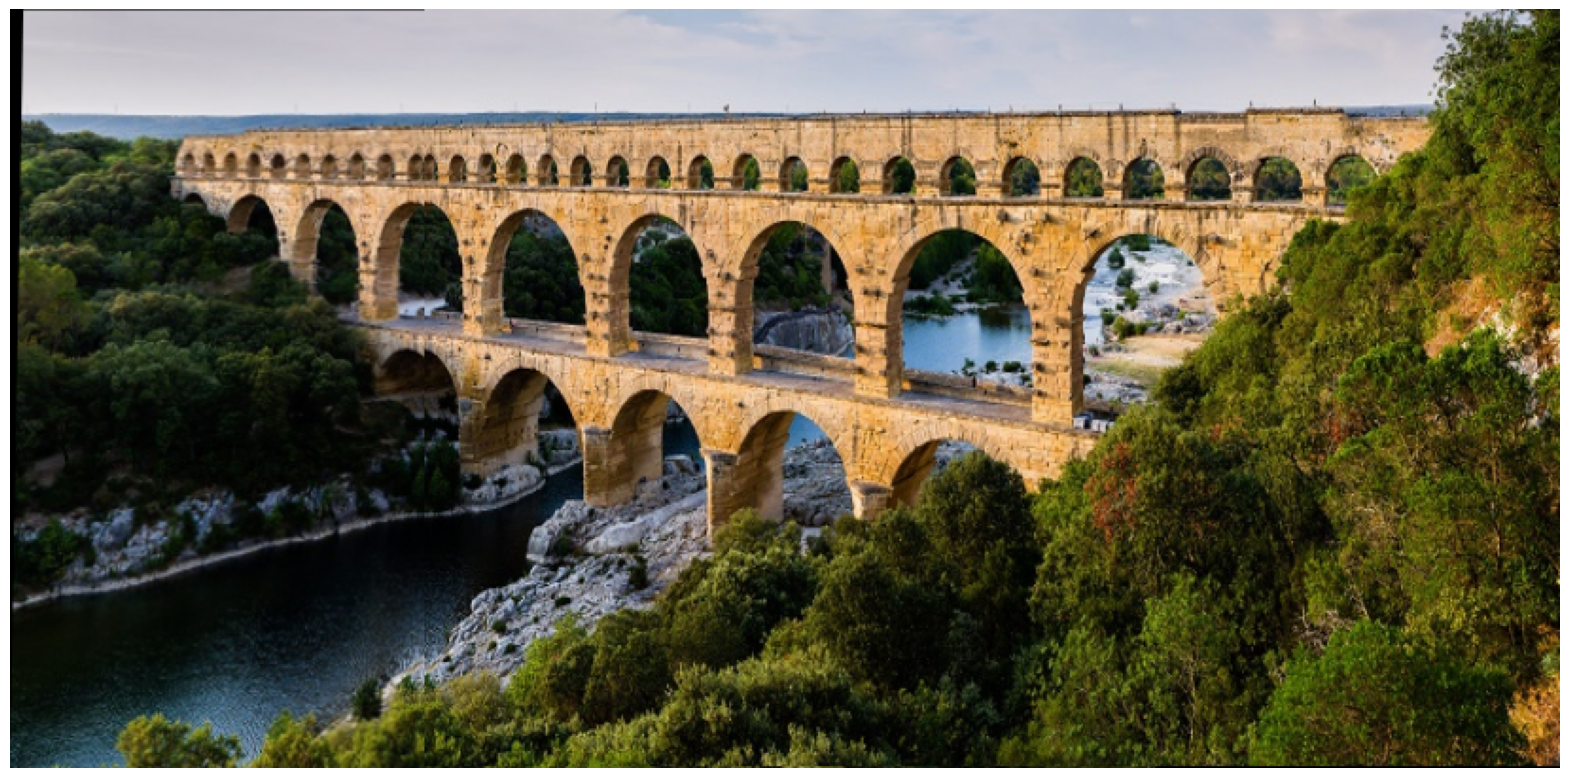

In [14]:
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

corners_img1 = np.float32([[0, 0], [w1, 0], [0, h1], [w1, h1]]).reshape(-1, 1, 2)

transformed_corners = cv2.perspectiveTransform(corners_img1, homografy)

min_x = min(transformed_corners[:, 0, 0].min(), 0)
min_y = min(transformed_corners[:, 0, 1].min(), 0)
max_x = max(transformed_corners[:, 0, 0].max(), w2)
max_y = max(transformed_corners[:, 0, 1].max(), h2)

new_w = int(max_x - min_x)
new_h = int(max_y - min_y)

translation_matrix = np.array([[1, 0, -min_x], [0, 1, -min_y], [0, 0, 1]])
homografy_adj = np.dot(translation_matrix, homografy)
result = cv2.warpPerspective(img1, homografy_adj, (new_w, new_h))
result[-int(min_y):h2 - int(min_y), -int(min_x):w2 - int(min_x)] = img2

plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## <font color=green> Ejercicio 7: Creación de un Panorama con Stitching de Imágenes</font>

**Objetivo:** Combinar dos imágenes utilizando "image stitching" para generar un panorama automático con OpenCV.

**Pasos:**
1. Definir las rutas de las imágenes en una lista.
2. Carga las imagenes img1.jpg y img2.jpg Leer las imágenes desde el disco usando `cv2.imread()`.
3. Redimensionar las imágenes con `cv2.resize()` si es necesario.
4. Mostrar las imágenes originales con `cv2_imshow()`.
5. Crear un objeto Stitcher con `cv2.Stitcher_create()`.
6. Aplicar la técnica de stitching con `stitcher.stitch()` para unir las imágenes.
7. Mostrar la imagen resultante `plt.imshow()`

Se genero correctamente


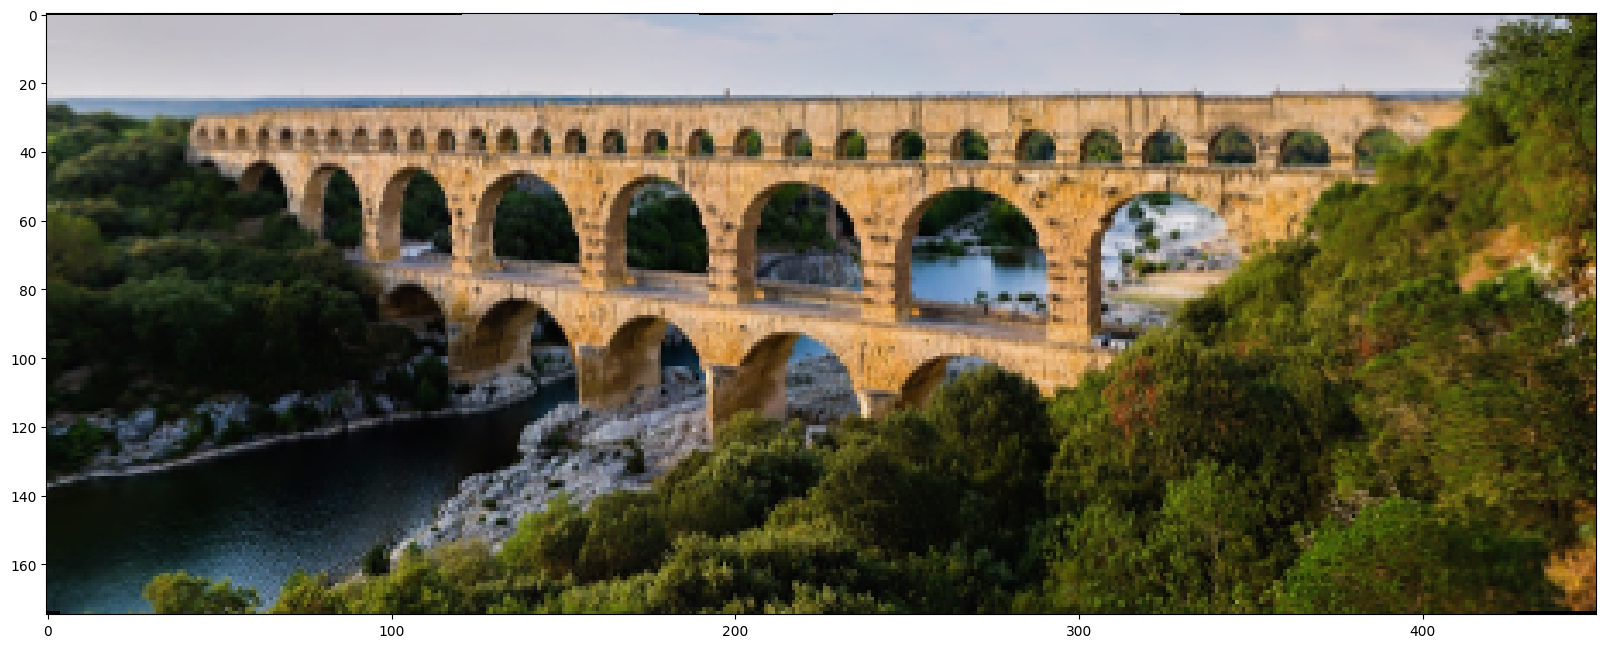

In [15]:
image_paths = ['data/img1.jpg', 'data/img2.jpg']
imgs = []

for i in range(len(image_paths)):
    imgs.append(cv2.imread(image_paths[i]))
    imgs[i] = cv2.resize(imgs[i], (0,0), fx=0.5, fy=0.5)

stitchy = cv2.Stitcher.create()
(dummy, output) = stitchy.stitch(imgs)

if dummy != cv2.Stitcher_OK:
    print("No se realizo stitching")
else:
    print("Se genero correctamente")

plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()